# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

In [2]:
pokemon = pd.read_csv(fp)

In [3]:
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

Text(0.5, 1.0, 'Pokemon Attack vs Defense with HP Distribution')

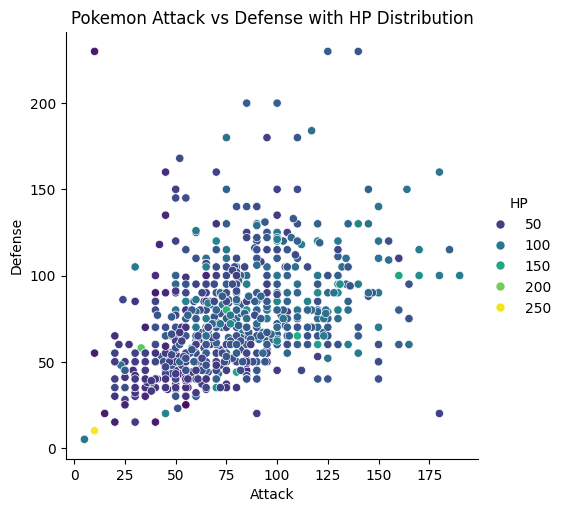

In [6]:
# Your code here . . .
sns.relplot(
    data = pokemon,
    x = 'Attack',
    y = 'Defense',
    hue = 'HP',
    palette = 'viridis'
)
plt.title('Pokemon Attack vs Defense with HP Distribution')

**Relationship Between Attack and Defense**
This plot shows a positive relationship between a Pokemon's Attack and Defense ratigs. Additionally, the HP of a Pokemon also seems to raise when its Attack and Defense values are higher.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.2, 'Pokemon Attack vs Total Rating Hexbins')

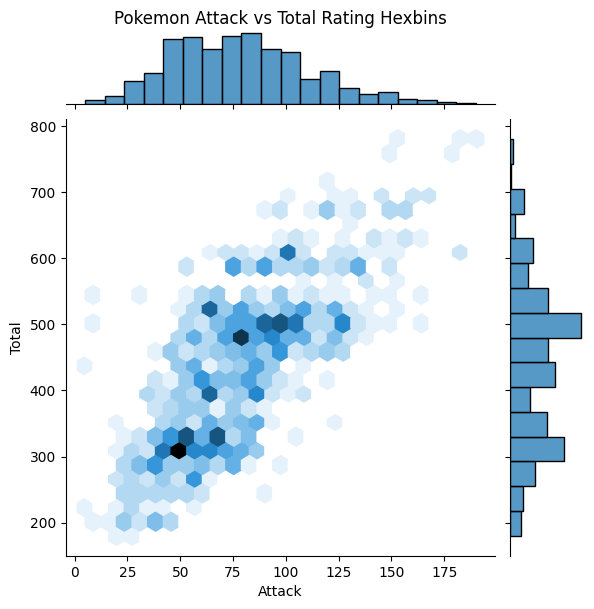

In [22]:
# Your code here . . .
sns.jointplot(
    data = pokemon,
    x = 'Attack',
    y = 'Total',
    kind = 'hex',
    gridsize = 25
)
plt.title('Pokemon Attack vs Total Rating Hexbins', y = 1.2)

From the plot, I observed....
There is a strong positive correlation between a Pokemon's total rating and a Pokemon's attack rating. Additionally, a lot of the data sits between 40-100 Attack points and 300-500 Total points.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

Text(0.5, 1.02, 'Distribution of Pokemon Type 2s')

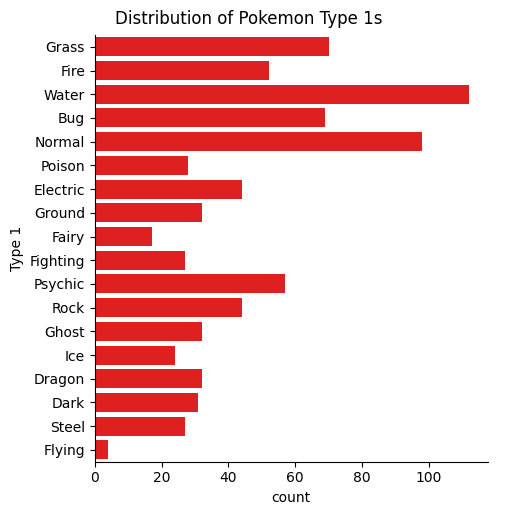

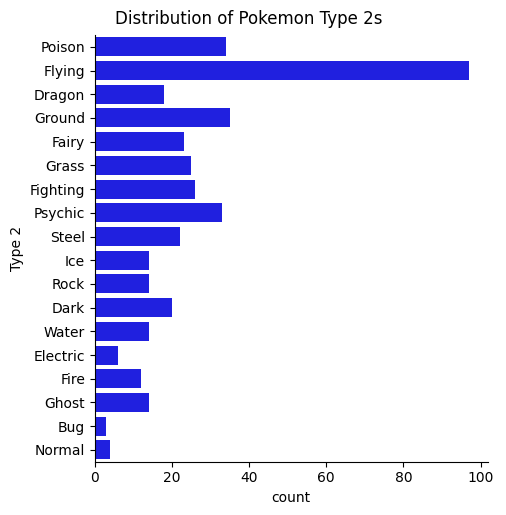

In [35]:
# Your code here . . .
t1 = sns.catplot(
    data = pokemon,
    y = 'Type 1',
    color = 'red',
    kind = 'count'
)
t1.fig.suptitle('Distribution of Pokemon Type 1s', y = 1.02)

t2 = sns.catplot(
    data = pokemon,
    y = 'Type 2',
    color = 'blue',
    kind = 'count'
)
t2.fig.suptitle('Distribution of Pokemon Type 2s', y = 1.02)

One apparent difference between these two charts is the difference in total data, as it seems there are many Pokemon that don't have two different Types. The most common Type 1s for Pokemon seem to be Water and Normal, while the most common Type 2 is Flying by far.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .
1. Does certain types tend to have more total HP?
2. Do Legendary Pokemon tend to be a certain Type?
3. Do Attack and Special Attack correlate?

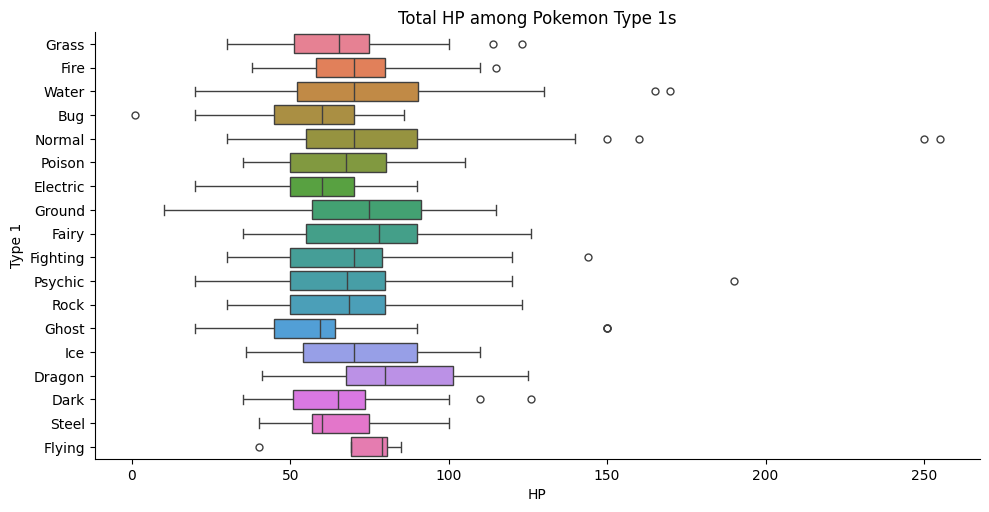

In [49]:
# Your code here . . .
#1 - Does certain types tend to have more total HP?
sns.catplot(
    data = pokemon,
    x = 'HP',
    y = 'Type 1',
    hue = 'Type 1',
    kind = 'box',
    aspect = 2,
)
plt.title('Total HP among Pokemon Type 1s');

Many of the Pokemon Types tend to be grouped around the same area of HP, but there are a few that are different. Normal seems to have the largest range of HP, while also having two outliers that are much higher than the rest of the data. Additonally, Ghost might have the lowest main grouping of HP, with the exception of one outlier at around 150 HP.

Text(0.5, 1.0, 'Distribution of Legendary Pokemon Type 1s')

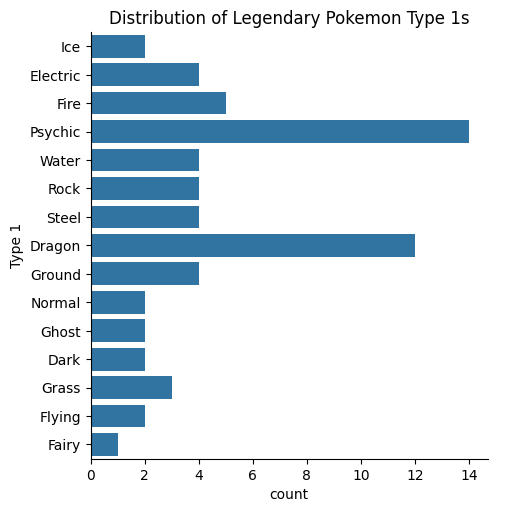

In [51]:
#2 - Do Legendary Pokemon tend to be a certain Type?
sns.catplot(
    data = pokemon[pokemon['Legendary'] == True],
    y = 'Type 1',
    kind = 'count'
)
plt.title('Distribution of Legendary Pokemon Type 1s')

This graph shows that Legendary Pokemon are most commonly Psychics or Dragons by far, and are least likely to be Fairy.

Text(0.5, 1.0, 'Pokemon Attack vs Special Attack')

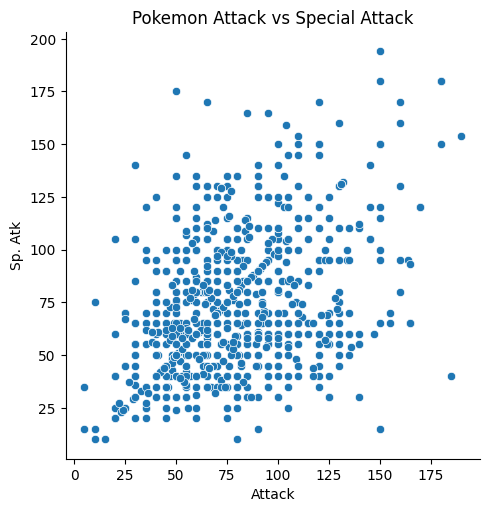

In [52]:
#3 - Do Attack and Special Attack correlate?
sns.relplot(
    data = pokemon,
    x = 'Attack',
    y = 'Sp. Atk',
)
plt.title('Pokemon Attack vs Special Attack')

While the data is pretty spread out, it seems that there is in fact a positive correlation between a Pokemon's regular and special attack ratings.